In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, make_moons, make_regression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.set_printoptions(precision=3, suppress=True)
RANDOM_STATE=7
rng = np.random.default_rng(RANDOM_STATE)

In [2]:
digits = load_digits()
X = digits.data.astype(float)
y = digits.target

print("X shape: ", X.shape)
print("Number of classes: ", len(np.unique(y)))

X shape:  (1797, 64)
Number of classes:  10


In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Dev data: ", X_dev.shape)
print("Test data: ", X_test.shape)

Dev data:  (1347, 64)
Test data:  (450, 64)


In [4]:
class LearningWithPrototype:
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        self.prototypes_ = np.vstack(
            [
                X[y==cls].mean(axis=0) for cls in self.classes_
            ]
        )
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        diffs = X[:, None, :] - self.prototypes_[None, :, :]
        dists = np.sqrt(np.sum(diffs**2, axis=2))
        nearest_neighbor_idx = np.argmin(dists, axis=1)
        return self.classes_[nearest_neighbor_idx]

    


In [5]:
def build_representation(X_train, X_eval, config):
    kind = config["kind"]
    if kind == "raw":
        return X_train, X_eval

    if kind == "standardized":
        scaler = StandardScaler()
        X_train_t = scaler.fit_transform(X_train)
        X_eval_t = scaler.transform(X_eval)
        return X_train_t, X_eval_t

    if kind == "pca":
        pca = PCA(
            n_components=config["n_components"],
            random_state=RANDOM_STATE,
        )
        X_train_t = pca.fit_transform(X_train)
        X_eval_t = pca.transform(X_eval)
        return X_train_t, X_eval_t

    raise ValueError("Unknown Configuration")

configs = [
    {"name": "raw pixels", "kind": "raw"},
    {"name": "standardized pixels", "kind": "raw"},
    {"name": "PCA-10", "kind": "pca", "n_components": 10},
    {"name": "PCA-20", "kind": "pca", "n_components": 20},
    {"name": "PCA-30", "kind": "pca", "n_components": 30},
    {"name": "PCA-40", "kind": "pca", "n_components": 40},
]
    

    

In [6]:
# data preprocessing evaluation

training_scores = []
for cfg in configs:
    X_train_rep, _ = build_representation(X_dev, X_dev, cfg)
    model = LearningWithPrototype().fit(X_train_rep, y_dev)
    train_pred = model.predict(X_train_rep)
    training_scores.append(
        (cfg["name"], accuracy_score(y_dev, train_pred))
    )

for name, score in training_scores:
    print(f"{name:<24} training accuracy = {score:.3f}")

# ambiguous results

raw pixels               training accuracy = 0.904
standardized pixels      training accuracy = 0.904
PCA-10                   training accuracy = 0.886
PCA-20                   training accuracy = 0.902
PCA-30                   training accuracy = 0.904
PCA-40                   training accuracy = 0.904


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size = 0.25,
    stratify=y_dev,
    random_state=RANDOM_STATE
)
print("Training set: ",X_train.shape)
print("Validation set: ", X_val.shape)

Training set:  (1010, 64)
Validation set:  (337, 64)


In [8]:
validation_results = []

for cfg in configs:
    X_train_rep, X_val_rep = build_representation(X_train, X_val, cfg)

    model = LearningWithPrototype().fit(X_train_rep, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train_rep))
    val_acc = accuracy_score(y_val, model.predict(X_val_rep))

    validation_results.append((cfg["name"], train_acc, val_acc))

for name, train_acc, val_acc in validation_results:
    print(
        f"{name:<24}"
        f" train={train_acc:.3f}"
        f" validation={val_acc:.3f}"
    )

raw pixels               train=0.909 validation=0.890
standardized pixels      train=0.909 validation=0.890
PCA-10                   train=0.887 validation=0.869
PCA-20                   train=0.904 validation=0.887
PCA-30                   train=0.907 validation=0.890
PCA-40                   train=0.909 validation=0.890


In [9]:
def validation_score_with_fixed_state(state, config):
    X_train, X_val, y_train, y_val = train_test_split(
        X_dev,
        y_dev,
        test_size=0.25,
        stratify=y_dev,
        random_state=state,
    )
    X_train_rep, X_val_rep = build_representation(X_train, X_val, config)
    model = LearningWithPrototype().fit(X_train_rep, y_train)
    return accuracy_score(y_val, model.predict(X_val_rep))



In [10]:
chosen_cfg = {"name": "PCA-20", "kind":"pca", "n_components": 20}
states = np.arange(40)
split_scores = np.array([
    validation_score_with_fixed_state(int(st), chosen_cfg)
    for st in states
])

print("Mean validation accuracy: ", split_scores.mean())
print("Standard Deviation: ", split_scores.std())
print("Minimum: ", split_scores.min())
print("Maximum: ", split_scores.max())

Mean validation accuracy:  0.8969584569732938
Standard Deviation:  0.014702470581970621
Minimum:  0.8635014836795252
Maximum:  0.9287833827893175


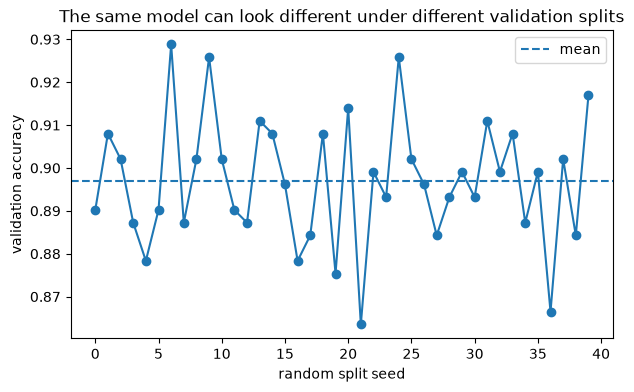

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(states, split_scores, marker="o")
plt.axhline(split_scores.mean(), linestyle="--", label="mean")
plt.xlabel("random split seed")
plt.ylabel("validation accuracy")
plt.title("The same model can look different under different validation splits")
plt.legend()
plt.show()


In [12]:
def cross_validate_lwp(X, y, config, n_splits=5, random_state = RANDOM_STATE):
    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_scores = []

    for fold_id, (train_idx, val_idx) in enumerate(splitter.split(X,y), start=1):
        X_tr, X_va = X[train_idx], X[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]

        X_tr_rep, X_val_rep = build_representation(X_tr, X_va, config)

        model = LearningWithPrototype().fit(X_tr_rep, y_tr)
        val_pred = model.predict(X_val_rep)

        score = accuracy_score(y_va, val_pred)
        fold_scores.append(score)

        print(f"Fold {fold_id}: {score:.3f}")

    fold_scores = np.array(fold_scores)

    print("Mean CV score: ", fold_scores.mean())
    print("Std. deviation: ", fold_scores.std())

    return fold_scores

In [13]:
cross_validate_lwp(
    X_dev, y_dev,
    {"name": "PCA-20", "kind":"pca", "n_components":20},
    n_splits=5
)

Fold 1: 0.907
Fold 2: 0.893
Fold 3: 0.914
Fold 4: 0.866
Fold 5: 0.881
Mean CV score:  0.8923420074349442
Std. deviation:  0.017496056565892724


array([0.907, 0.893, 0.914, 0.866, 0.881])

In [14]:
cv_summary = []

for cfg in configs:
    splitter = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    scores = []

    for train_idx, val_idx in splitter.split(X_dev, y_dev):
        X_tr, X_va = X_dev[train_idx], X_dev[val_idx]
        y_tr, y_va = y_dev[train_idx], y_dev[val_idx]

        X_tr_rep, X_va_rep = build_representation(X_tr, X_va, cfg)

        model = LearningWithPrototype().fit(X_tr_rep, y_tr)
        pred = model.predict(X_va_rep)

        scores.append(accuracy_score(y_va, pred))

    cv_summary.append(
        {
            "name": cfg["name"],
            "mean": np.mean(scores),
            "std": np.std(scores),
            "config": cfg,
        }
    )

for row in cv_summary:
    print(f"{row['name']:<24} CV mean={row['mean']:.3f} +/- {row['std']:.3f}")

best = max(cv_summary, key=lambda row: row["mean"])
print()
print("Selected configuration:", best["name"])


raw pixels               CV mean=0.894 +/- 0.017
standardized pixels      CV mean=0.894 +/- 0.017
PCA-10                   CV mean=0.883 +/- 0.021
PCA-20                   CV mean=0.892 +/- 0.017
PCA-30                   CV mean=0.892 +/- 0.018
PCA-40                   CV mean=0.892 +/- 0.017

Selected configuration: raw pixels


In [15]:
# test accuracy
best_cfg = best["config"]

X_dev_rep, X_test_rep = build_representation(
    X_dev,
    X_test,
    best_cfg,
)

final_model = LearningWithPrototype().fit(X_dev_rep, y_dev)
final_test_pred = final_model.predict(X_test_rep)

final_test_acc = accuracy_score(y_test, final_test_pred)

print("Chosen configuration:", best_cfg["name"])
print("Final held-out test accuracy:", final_test_acc)


Chosen configuration: raw pixels
Final held-out test accuracy: 0.8977777777777778
